# Flausch detection

## Data Preparation

In [1]:
import pandas as pd
import os
import sys
import numpy as np
#path = "Input/Data/train/"
path = ""
file = "comments.csv"
data = pd.read_csv(path + file, encoding='utf-8')
task1 = pd.read_csv(path + "task1.csv", encoding='utf-8')
task2 = pd.read_csv(path + "task2.csv", encoding='utf-8')

In [2]:
# comments and task1 are original datasets. They are merged to create data.
# if translations are avaiable "data_translated.csv" then use that instead.
# For translating data see below (takes a lot of time)
# currently the data has been tranlated with Helsinki-NLP/opus-mt-en-de

if os.path.exists(path + "translated_data.csv"):
    data = pd.read_csv(path + "translated_data.csv", encoding='utf-8')
else:
    # Merge comments and task1 datasets
    data = pd.merge(data, task1, on=["comment_id","document"], how = "outer")

data2 = pd.merge(task2,data, on=["comment_id","document"], how = "left")

print(data.shape, data2.shape, task1.shape, task2.shape)
data.columns, data2.columns

(37057, 5) (15799, 8) (37057, 3) (15799, 5)


(Index(['document', 'comment_id', 'comment', 'flausch', 'translated'], dtype='object'),
 Index(['document', 'comment_id', 'type', 'start', 'end', 'comment', 'flausch',
        'translated'],
       dtype='object'))

In [3]:
# add span-column to data2. span contains the text span that is annotated with flausch type
data2["span"] = data2.apply(lambda row: row["comment"][row["start"]:(row["end"]+1)], axis=1)

In [4]:
data2.head(3)


,document,comment_id,type,start,end,comment,flausch,translated,span
0,NDY-003,1,compliment,0,11,Respekt : o zu mir passt das heut vollkommen :...,yes,Respect : o to me this fits perfectly today :(...,Respekt : o
1,NDY-003,1,compliment,48,71,Respekt : o zu mir passt das heut vollkommen :...,yes,Respect : o to me this fits perfectly today :(...,Aber Respekt an euch ;)
2,NDY-003,2,positive feedback,0,12,haha geil :D aber ich hab mich am anfang etwas...,yes,haha horny :D but I got a little scared at the...,haha geil :D


In [8]:
# function to get all spans for a comment.
# Returns list of spans, list of start-end-pairs and list of flausch types for a given document and comment id.
def get_all_spans(doc,id,comment,task2):
    doc_bool = np.array(task2["document"] == doc)
    id_bool = np.array(task2["comment_id"] == id)
    bool = doc_bool & id_bool
    sub = task2[bool].reset_index()
    spans = []
    span_pairs = []
    types = []
    for i in range(len(sub)):
        s = sub["start"][i]
        e = sub["end"][i]
        spans.append(comment[s:e])
        span_pairs.append((s,e))
        types.append(sub["type"][i])
    return spans, span_pairs, types



In [9]:
# adds columns spans, span-pairs and types to data
# values are lists that are empty if flausch == no
data["spans"] = data.apply(lambda x: get_all_spans(x["document"], x["comment_id"], x["comment"],task2),axis=1)
data["span_pairs"] = data["spans"].apply(lambda x: x[1])
data["types"] = data["spans"].apply(lambda x: x[2])
data["spans"] = data["spans"].apply(lambda x: x[0])

In [10]:
data[data["flausch"]=="yes"].head(3)

,document,comment_id,comment,flausch,translated,spans,span_pairs,types
0,NDY-003,1,Respekt : o zu mir passt das heut vollkommen :...,yes,Respect : o to me this fits perfectly today :(...,"[Respekt : o, Aber Respekt an euch ;)]","[(0, 11), (48, 71)]","[compliment, compliment]"
1,NDY-003,2,haha geil :D aber ich hab mich am anfang etwas...,yes,haha horny :D but I got a little scared at the...,[haha geil :D],"[(0, 12)]",[positive feedback]
2,NDY-003,3,würd gern mit euch tanzen * - * haha,yes,Would like to dance with you * - * haha,[würd gern mit euch tanzen * - *],"[(0, 31)]",[positive feedback]


### Data Analysis

In [11]:
print("Flausch yes/no distribution:")
task1["flausch"].value_counts()

Flausch yes/no distribution:


,count
flausch,
no,26284
yes,10773


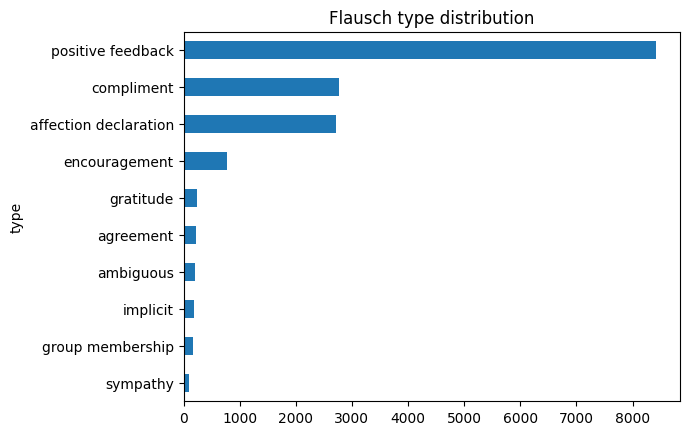

In [12]:

import matplotlib.pyplot as plt
task2["type"].value_counts(ascending=True).plot.barh()
plt.title("Flausch type distribution")
plt.show()

In [13]:
print("length of comments:")
data["comment"].apply(lambda x: len(x)).describe()

length of comments:


,comment
count,37057.000000
mean,58.345090
std,103.581884
min,1.000000
25%,18.000000
50%,35.000000
75%,68.000000
max,9529.000000


In [14]:
print("Number of words in comments:")
data["comment"].apply(lambda x: len(x.split())).describe()

Number of words in comments:


,comment
count,37057.000000
mean,11.594571
std,20.462793
min,1.000000
25%,4.000000
50%,7.000000
75%,14.000000
max,1880.000000


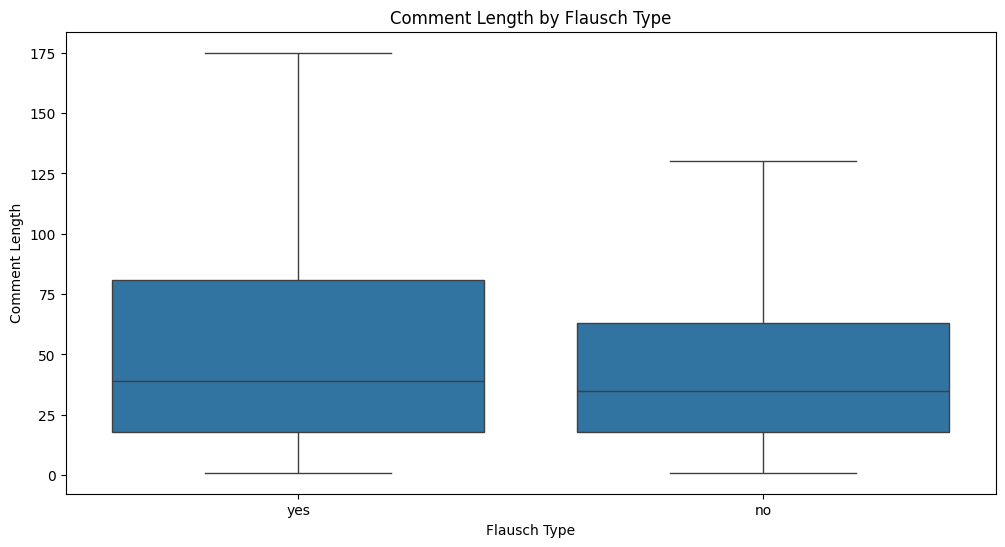

In [15]:
#  plot per flausch yes/no boxplots of comment length
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.boxplot(x="flausch", y=data["comment"].apply(lambda x: len(x)), data=data,showfliers=False,)
plt.title("Comment Length by Flausch Type")
plt.xlabel("Flausch Type")
plt.ylabel("Comment Length")
plt.show()

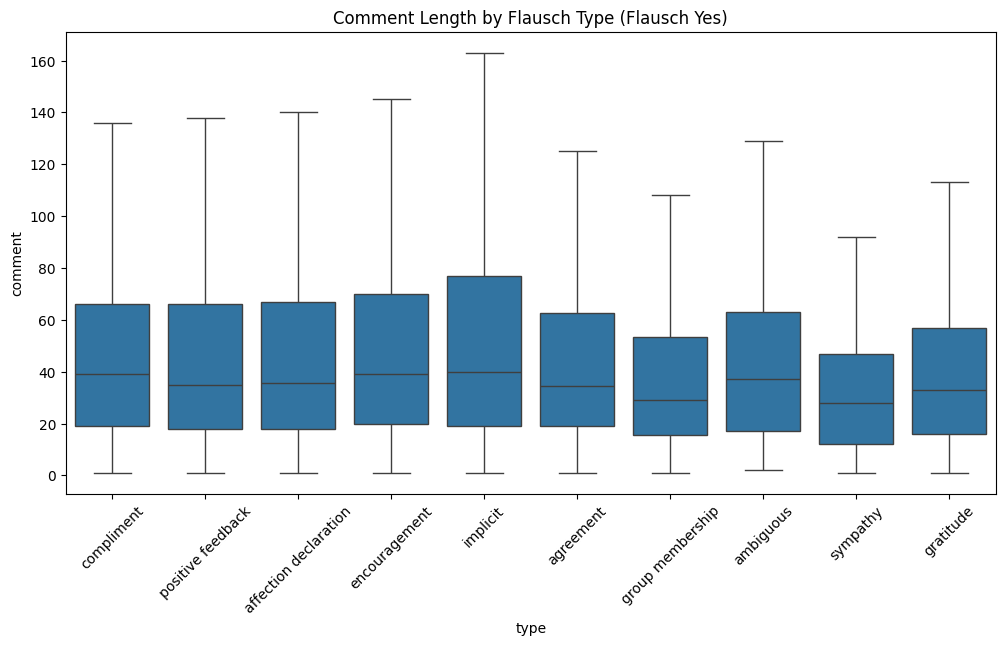

In [16]:
# plot per flausch type the boxplot of the comment length
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.boxplot(x="type", y=data["comment"].apply(lambda x: len(x)), data=data2[data2["flausch"]=="yes"],showfliers=False)
plt.title("Comment Length by Flausch Type (Flausch Yes)")
# x-axis label rotation
plt.xticks(rotation=45)
plt.show()

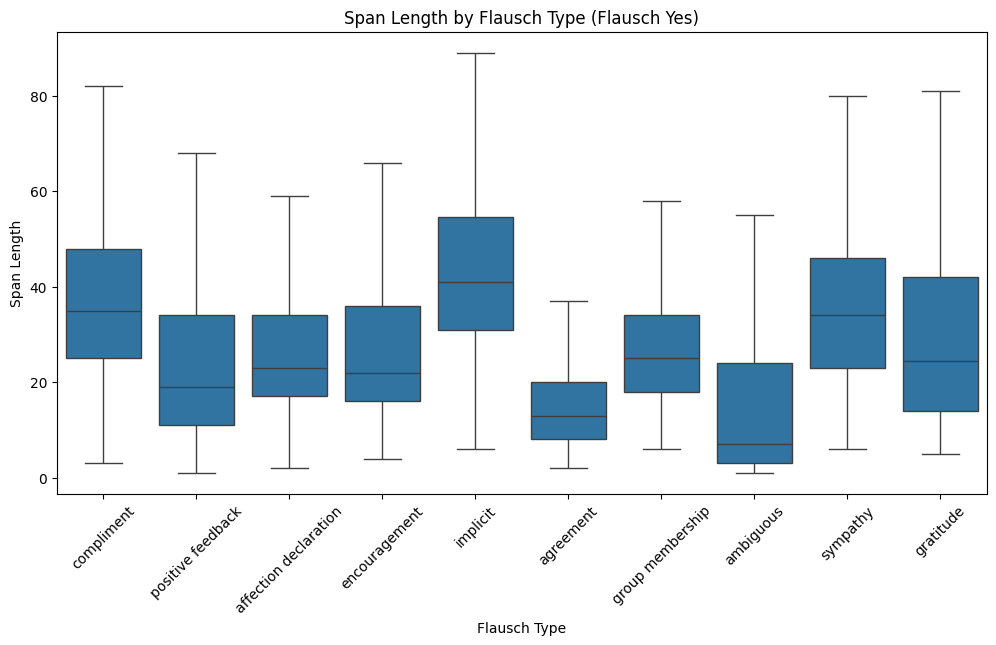

In [17]:
# plot per flausch type boxplot for span length
plt.figure(figsize=(12, 6))
sns.boxplot(x="type", y=data2["span"].apply(lambda x: len(x)), data=data2[data2["flausch"]=="yes"],showfliers=False)
plt.title("Span Length by Flausch Type (Flausch Yes)")
plt.xlabel("Flausch Type")
plt.ylabel("Span Length")
# x-axis label rotation
plt.xticks(rotation=45)

plt.show()

## Token Classifier (Dataset and Training for Task 2)
### Create Dataset

In [ ]:
from transformers import AutoTokenizer
checkpoint = "deepset/gbert-large"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)


In [ ]:
dataflausch = data[data["flausch"]=="yes"].reset_index(drop=True)

In [ ]:
tags = sorted(task2["type"].unique())
tag2id = {'O': 0}
for i, tag in enumerate(tags):
    tag2id["I-"+ tag] = 2*i +1
    tag2id["B-"+ tag] = 2*(i+1)

id2tag = {v: k for k, v in tag2id.items()}


In [ ]:
def align_labels_with_tokens(tokenizer, data, tag2id):
    # Tokenisiere den Text und erhalte Offsets
    text = data["comment"]
    types = data["types"]  # Liste von Typen für die Spans
    span_pairs = data["span_pairs"]  # Liste von Spans, die gelabelt werden sollen
    tokenized_input = tokenizer(text, return_offsets_mapping=True, truncation=True, max_length=512)
    # encodings[0] für den einzelnen Text
    encoding = tokenized_input.encodings[0]

    token_ids = encoding.ids  # Token-IDs

    label_ids = [tag2id['O'] for i in  range(len(encoding.tokens))]  # Initialisiere mit O-Labels für jedes Wort/Token


    # Iteriere über jeden Span, der gelabelt werden soll
    for i in range(len(span_pairs)):
        span_start_char = span_pairs[i][0]
        span_end_char = span_pairs[i][1]
        span_type = types[i]

        # Finde die Token-Indizes, die diesen Span abdecken
        token_start_idx = encoding.char_to_token(span_start_char)
        token_end_idx = encoding.char_to_token(span_end_char - 1) # end_char ist exklusiv

        # Wenn der Span nicht durch die Tokenisierung abgedeckt wird (z.B. wegen Truncation)
        if token_start_idx is None or token_end_idx is None:
            continue

        # Wenn der Span über mehrere Tokens geht oder ein einzelnes Token ist
        for current_token_idx in range(token_start_idx, token_end_idx + 1):
            if current_token_idx == token_start_idx:
                # Dies ist das erste Token, das den Span abdeckt -> B-Tag
                label_ids[current_token_idx] = tag2id["B-"+span_type]
            else:
                # Alle nachfolgenden Tokens, die denselben Span abdecken -> I-Tag
                # Alle Tokens vom Start bis Ende des Spans sind entweder B oder I.
                # Das erste ist B, der Rest I.

                # Wenn token_start_idx == token_end_idx (einzelnes Token für Span), ist es B.
                # Wenn token_start_idx != token_end_idx, dann erstes ist B, der Rest ist I.
                label_ids[current_token_idx] = tag2id["I-"+ span_type]

    return tokenized_input["input_ids"], label_ids



In [ ]:
i=3
input_ids, label_ids = align_labels_with_tokens(tokenizer, dataflausch.loc[i], tag2id)
ex_spans = dataflausch["spans"][i]

print(ex_spans)
for idx,j in enumerate(label_ids):
    if j != 0:
        print(id2tag[j], tokenizer.decode(input_ids[idx]))

['Einfach nur wieder geil', 'ich mag eure texte voll und eure stimmen', 'sind voll die ohrwürmer =D', 'Daumen hoch =)']
B-positive feedback Einfach
I-positive feedback nur
I-positive feedback wieder
I-positive feedback ge
I-positive feedback ##il
B-compliment ich
I-compliment mag
I-compliment eure
I-compliment te
I-compliment ##xt
I-compliment ##e
I-compliment voll
I-compliment und
I-compliment eure
I-compliment stimmen
B-positive feedback sind
I-positive feedback voll
I-positive feedback die
I-positive feedback oh
I-positive feedback ##rw
I-positive feedback ##ürmer
I-positive feedback =
I-positive feedback D
B-positive feedback Daumen
I-positive feedback hoch
I-positive feedback =
I-positive feedback )


In [ ]:
import pandas as pd
from datasets import Dataset, Features, Value, ClassLabel, Sequence
from sklearn.model_selection import train_test_split # Für den Split in Train/Test



all_input_ids = []
all_labels = []

print("Beginne mit der Vorverarbeitung des DataFrames...")
for idx, row in dataflausch.iterrows():
    input_ids_for_text, labels_for_text = align_labels_with_tokens(tokenizer, row, tag2id)

    # Sammle die Ergebnisse
    all_input_ids.append(input_ids_for_text)
    all_labels.append(labels_for_text)

    if (idx + 1) % 1000 == 0: # Fortschrittsanzeige alle 1000 Texte
        print(f"Verarbeitete {idx + 1}/{len(dataflausch)} Texte.")

print("Alle Texte erfolgreich vorverarbeitet.")
print(f"Anzahl vorbereiteter Beispiele: {len(all_input_ids)}")



max_label_id = max(id2tag.keys())
id2tag_ordered_list = [None] * (max_label_id + 1) # Erstelle eine Liste der richtigen Größe
for k, v in id2tag.items():
    id2tag_ordered_list[k] = v

features = Features({
    'input_ids': Sequence(Value('int32')), # Sequenz von Ganzzahlen für Token-IDs
    'labels': Sequence(ClassLabel(names=id2tag_ordered_list)) # Sequenz von ClassLabels für NER-Tags
})

# Erstelle ein Dictionary, das die Daten enthält
dataset_dict = {
    'input_ids': all_input_ids,
    'labels': all_labels
}

# Erstelle ein Dataset aus dem Dictionary und den definierten Features
prepared_dataset = Dataset.from_dict(dataset_dict, features=features)

print("\nHugging Face Dataset erfolgreich erstellt.")
print(prepared_dataset)
print("\nBeispiel des ersten Eintrags im Dataset:")
print(prepared_dataset[0])

# Überprüfe den ersten Eintrag noch einmal visuell
first_text = dataflausch["comment"].iloc[0] # .iloc[0] für den ersten Eintrag im DF
first_input_ids = prepared_dataset[0]['input_ids']
first_labels_ids = prepared_dataset[0]['labels']

print(f"\nOriginaltext (erster Eintrag): '{first_text}'")
print(f"Token (decoded): {[tokenizer.decode(t) for t in first_input_ids]}")
print(f"Labels (decoded): {[id2tag[l] for l in first_labels_ids]}")


# Teile das Dataset in Trainings- Dev- und Testsets auf (80% Training, 10% Development, 10% Test)
split_dataset = prepared_dataset.train_test_split(test_size=0.2, seed=42)
train_dataset = split_dataset['train']
dev_test_dataset = split_dataset['test']
# Teile das Dev-Testset weiter in Dev und Test (50% Dev, 50% Test)
dev_test_split = dev_test_dataset.train_test_split(test_size=0.5, seed=42)
dev_dataset = dev_test_split['train']
test_dataset = dev_test_split['test']

# create one datasetdict for train, dev and test
from datasets import DatasetDict
dataset_dict = DatasetDict({
    'train': train_dataset,
    'dev': dev_dataset,
    'test': test_dataset
})

print(f"\nTrainingsdatensatzgröße: {len(train_dataset)}")
print(f"Entwicklungsdatensatzgröße: {len(dev_dataset)}")
print(f"Testdatensatzgröße: {len(test_dataset)}")



Beginne mit der Vorverarbeitung des DataFrames...
Verarbeitete 1000/10773 Texte.
Verarbeitete 2000/10773 Texte.
Verarbeitete 3000/10773 Texte.
Verarbeitete 4000/10773 Texte.
Verarbeitete 5000/10773 Texte.
Verarbeitete 6000/10773 Texte.
Verarbeitete 7000/10773 Texte.
Verarbeitete 8000/10773 Texte.
Verarbeitete 9000/10773 Texte.
Verarbeitete 10000/10773 Texte.
Alle Texte erfolgreich vorverarbeitet.
Anzahl vorbereiteter Beispiele: 10773

Hugging Face Dataset erfolgreich erstellt.
Dataset({
    features: ['input_ids', 'labels'],
    num_rows: 10773
})

Beispiel des ersten Eintrags im Dataset:
{'input_ids': [102, 12460, 853, 256, 205, 780, 10576, 199, 2969, 30885, 11967, 853, 201, 1124, 12460, 208, 2624, 3464, 2530, 103], 'labels': [0, 8, 7, 7, 0, 0, 0, 0, 0, 0, 0, 0, 0, 8, 7, 7, 7, 7, 7, 0]}

Originaltext (erster Eintrag): 'Respekt : o zu mir passt das heut vollkommen :( Aber Respekt an euch ;)'
Token (decoded): ['[CLS]', 'Respekt', ':', 'o', 'zu', 'mir', 'passt', 'das', 'heu', '##t', 'vol

In [ ]:
example = dataset_dict["train"][0]
example
pd.DataFrame([tokenizer.decode(x) for x in example["input_ids"]], [id2tag[x] for x in example["labels"]]).T#.rename(columns={0: 'Tokens', 1: 'Tags'})



,O,B-affection declaration,I-affection declaration,I-affection declaration,O
0,[CLS],Ihr,seid,cool,[SEP]


In [ ]:
dataset_dict["train"].features["labels"].feature.names

['O',
 'I-affection declaration',
 'B-affection declaration',
 'I-agreement',
 'B-agreement',
 'I-ambiguous',
 'B-ambiguous',
 'I-compliment',
 'B-compliment',
 'I-encouragement',
 'B-encouragement',
 'I-gratitude',
 'B-gratitude',
 'I-group membership',
 'B-group membership',
 'I-implicit',
 'B-implicit',
 'I-positive feedback',
 'B-positive feedback',
 'I-sympathy',
 'B-sympathy']

In [ ]:
from collections import defaultdict, Counter

retrieved_id2tag_ordered_list = train_dataset.features['labels'].feature.names

# Initialisiere das Dictionary, um die Häufigkeiten zu speichern
split2freqs = defaultdict(Counter)


# Iteriere durch die Splits
for split_name, dataset_split in split_dataset.items():
    # Iteriere durch jedes Beispiel im aktuellen Dataset-Split
    for example in dataset_split:
        label_ids_for_example = example['labels']
        for label_id in label_ids_for_example:
            # Konvertiere die numerische Label-ID zurück in den String-Tag
            tag_str = retrieved_id2tag_ordered_list[label_id]

            # Prüfe, ob es sich um einen "B-" Tag handelt
            if tag_str.startswith("B-"):
                # Extrahiere den eigentlichen Entitätstyp (z.B. "ORG" aus "B-ORG")
                tag_type = tag_str.split("-")[1]
                # Inkrementiere den Zähler für diesen Split und diesen Entitätstyp
                split2freqs[split_name][tag_type] += 1

# Erstelle ein Pandas DataFrame aus den gesammelten Häufigkeiten für eine bessere Übersicht
label_frequency_df = pd.DataFrame.from_dict(split2freqs, orient="index").fillna(0).astype(int)

label_frequency_df


,affection declaration,positive feedback,compliment,implicit,group membership,agreement,encouragement,ambiguous,gratitude,sympathy
train,2167,6668,2230,150,139,180,615,166,185,75
test,510,1727,535,33,28,43,152,47,49,20


In [ ]:
dataset_dict["test"].features

{'input_ids': Sequence(feature=Value(dtype='int32', id=None), length=-1, id=None),
 'labels': Sequence(feature=ClassLabel(names=['O', 'I-affection declaration', 'B-affection declaration', 'I-agreement', 'B-agreement', 'I-ambiguous', 'B-ambiguous', 'I-compliment', 'B-compliment', 'I-encouragement', 'B-encouragement', 'I-gratitude', 'B-gratitude', 'I-group membership', 'B-group membership', 'I-implicit', 'B-implicit', 'I-positive feedback', 'B-positive feedback', 'I-sympathy', 'B-sympathy'], id=None), length=-1, id=None)}

In [ ]:
# huggingface login
from huggingface_hub import login
login()


In [ ]:
# dataset to huggingface

dataset_dict.push_to_hub("Wiebke/FlauschSpans", private=False)

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/9 [00:00<?, ?ba/s]

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/3 [00:00<?, ?ba/s]

CommitInfo(commit_url='https://huggingface.co/datasets/Wiebke/FlauschSpans/commit/55d02e5ac042e641e0f984f81196f121697006df', commit_message='Upload dataset', commit_description='', oid='55d02e5ac042e641e0f984f81196f121697006df', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/Wiebke/FlauschSpans', endpoint='https://huggingface.co', repo_type='dataset', repo_id='Wiebke/FlauschSpans'), pr_revision=None, pr_num=None)

### Evaluation Metric



In [ ]:
dataset = dataset_dict

In [ ]:
#!pip install seqeval

In [ ]:
#!pip install --upgrade seqeval

In [ ]:
import evaluate
seqeval = evaluate.load("seqeval")

In [ ]:
import numpy as np
from seqeval.metrics import f1_score, precision_score, recall_score, classification_report


tags = dataset["train"].features['labels'].feature.names

tag2id = {name: i for i, name in enumerate(tags)}
id2tag = {i: name for i, name in enumerate(tags)}

label_list = list(tag2id.keys())

from seqeval.metrics import f1_score, precision_score, recall_score, classification_report

# Annahme: Diese Variablen sind bereits GLOBAL in deinem Skript definiert:
# tags = dataset["train"].features['labels'].feature.names
# tag2id = {name: i for i, name in enumerate(tags)}
# id2tag = {i: name for i, name in enumerate(tags)}
# label_list = list(tag2id.keys()) # Dies ist die Liste aller deiner String-Labels (z.B. ['O', 'B-affection declaration', ...])

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    # Konvertierung der numerischen IDs zurück zu den Label-Strings
    # und Entfernen von Padding-Tokens (-100)
    true_labels = []
    for label_sequence in labels:
        true_labels.append([id2tag[l] for l in label_sequence if l != -100])

    true_predictions = []
    for prediction_sequence, label_sequence in zip(predictions, labels):
        true_predictions.append([
            id2tag[p] for p, l in zip(prediction_sequence, label_sequence) if l != -100
        ])

    # Berechne Metriken mit explizitem zero_division=0
    # Dies ist der Standard von seqeval und sorgt dafür, dass undefinierte Werte 0.0 werden.
    # Es hilft, die UndefinedMetricWarning zu kontrollieren.
    precision = precision_score(true_labels, true_predictions, zero_division=0)
    recall = recall_score(true_labels, true_predictions, zero_division=0)
    f1 = f1_score(true_labels, true_predictions, zero_division=0)

    # Generiere und gib den detaillierten Klassifikationsbericht aus.
    # Das `labels=label_list` Argument stellt sicher, dass alle deine definierten Labels
    # im Bericht erscheinen, auch wenn sie im aktuellen Batch nicht vorkommen.
    report = classification_report(
        true_labels,
        true_predictions,
        digits=4, # Anzahl der Dezimalstellen im Bericht
        zero_division=0, # Steuerung der 0-Division für den Bericht
        #labels=label_list # Wichtig, um alle Labels im Bericht zu haben führt aber zu Versionsproblemen
    )

    print("\n--- Classification Report (Aktueller Evaluationsschritt) ---")
    print(report)
    print("-----------------------------------------------------------")

    return {"precision": precision, "recall": recall, "f1": f1}




In [ ]:
from transformers import DataCollatorForTokenClassification
data_collator = DataCollatorForTokenClassification(tokenizer)

### Training

In [ ]:
# load model with the correct head for token classification with the number of labels
from transformers import AutoModelForTokenClassification, TrainingArguments, Trainer

num_labels = len(tag2id)  # Anzahl der Labels

model = AutoModelForTokenClassification.from_pretrained(
    checkpoint, num_labels=num_labels, id2label=id2tag, label2id=tag2id
)

Some weights of BertForTokenClassification were not initialized from the model checkpoint at deepset/gbert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
from transformers import pipeline
i=12
text = tokenizer.decode(dataset["test"]["input_ids"][i])
classifier = pipeline("ner", model=model, tokenizer=tokenizer)

print(text)
for d in classifier(text):
  print(d["word"], d["entity"])

Device set to use cuda:0


OutOfMemoryError: CUDA out of memory. Tried to allocate 122.00 MiB. GPU 0 has a total capacity of 14.74 GiB of which 54.12 MiB is free. Process 20452 has 14.69 GiB memory in use. Of the allocated memory 14.10 GiB is allocated by PyTorch, and 458.54 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
#!pip install -U --user accelerate>=0.26.0

In [ ]:
from transformers import TrainingArguments, Trainer
import os



# Define training parameters
training_args = TrainingArguments(
    output_dir="flausch_span_model", # Verzeichnis für Modell, Checkpoints und Logs
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    weight_decay=0.01, # Gewichtszerfall zur Regularisierung
    eval_strategy="epoch", # Evaluierung nach jeder Epoche
    save_strategy="epoch", # Speichern des Modells nach jeder Epoche
    load_best_model_at_end=True, # Lädt das beste Modell am Ende des Trainings

    # Metrik für das beste Modell. Für NER ist F1-Score üblich.
    # Wichtig: compute_metrics Funktion muss einen F1-Score zurückgeben.
    metric_for_best_model="f1",
    greater_is_better=True, # Für F1-Score ist größer besser

    logging_steps=100, # Logge Metriken alle 100 Schritte
    save_total_limit=1, # Behält nur das beste Modell und das letzte Checkpoint

    # NEU: Für schnellere Trainingszeiten auf GPUs (wie in Colab)
    # Colab T4 GPUs unterstützen fp16
    fp16=True,

    # NEU: Eindeutiger Name für den W&B Lauf (optional, vermeidet Warnung)
    run_name="flausch_ner_training_run", # Ein beschreibender Name für deinen W&B Lauf

    # NEU: Wohin die Logs gemeldet werden sollen
    # "wandb" für Weights & Biases
    # "tensorboard" für TensorBoard
    # "all" für beides (wenn installiert)
    # "none" um alle Reporting-Tools zu deaktivieren (wenn du keine nutzen willst)
    report_to="none",

    # push_to_hub=True wird hier beibehalten, da es das Modell hochlädt.
    # Beachte aber, dass es die Dataset-Metadaten nicht automatisch generiert.
    push_to_hub=True,
)

# Define Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["dev"],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics, # Eigene Funktion zur Metrikberechnung
)


<ipython-input-114-ec16d177fb8f>:46: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
print("\nPredictions on test data before training:")

# Die predict-Methode gibt ein Objekt zurück, das die Vorhersagen,
# die echten Labels und die Metriken enthält (falls der Trainer diese selbst berechnet hat).
predictions_output = trainer.predict(test_dataset=dataset["test"])



Predictions on test data before training:



--- Classification Report (Aktueller Evaluationsschritt) ---
                       precision    recall  f1-score   support

affection declaration     0.0003    0.0039    0.0006       510
            agreement     0.0000    0.0000    0.0000        43
            ambiguous     0.0000    0.0000    0.0000        47
           compliment     0.0000    0.0000    0.0000       535
        encouragement     0.0000    0.0000    0.0000       152
            gratitude     0.0000    0.0000    0.0000        49
     group membership     0.0000    0.0000    0.0000        28
             implicit     0.0000    0.0000    0.0000        33
    positive feedback     0.0048    0.0023    0.0031      1728
             sympathy     0.0000    0.0000    0.0000        21

            micro avg     0.0005    0.0019    0.0008      3146
            macro avg     0.0005    0.0006    0.0004      3146
         weighted avg     0.0027    0.0019    0.0018      3146

-----------------------------------------------------

In [ ]:

# Training
trainer.train()


Epoch,Training Loss,Validation Loss


OutOfMemoryError: CUDA out of memory. Tried to allocate 64.00 MiB. GPU 0 has a total capacity of 14.74 GiB of which 54.12 MiB is free. Process 20452 has 14.69 GiB memory in use. Of the allocated memory 14.10 GiB is allocated by PyTorch, and 458.22 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
i=12
text = tokenizer.decode(dataset["test"]["input_ids"][i])
classifier = pipeline("ner", model=model, tokenizer=tokenizer)

print(text)
for d in classifier(text):
  print(d["word"], d["entity"])

In [ ]:

print("\nPredictions on test set after training.")

# Die predict-Methode gibt ein Objekt zurück, das die Vorhersagen,
# die echten Labels und die Metriken enthält (falls der Trainer diese selbst berechnet hat).
predictions_output = trainer.predict(test_dataset=dataset["test"])

# Die compute_metrics Funktion erwartet ein Tupel (predictions, labels)
# predictions_output.predictions sind die Rohergebnisse (logits) des Modells
# predictions_output.label_ids sind die echten Labels des Test-Sets
#final_metrics = compute_metrics((predictions_output.predictions, predictions_output.label_ids))



In [ ]:
trainer.push_to_hub()

## Dataset and training for task 1

In [9]:
import pandas as pd
from datasets import Dataset, DatasetDict


label_mapping = {'no': 0, 'yes': 1}
data['labels'] = data['flausch'].map(label_mapping)
id2label = {0: 'no', 1: 'yes'}
label2id = {'no': 0, 'yes': 1}

# Convert to Hugging Face Dataset

dataset = Dataset.from_pandas(data)

train_val_test_split = dataset.train_test_split(test_size=0.2, seed=42)
train_dataset = train_val_test_split["train"] # 80%
test_dev_dataset = train_val_test_split["test"] # 20%
dev_test_split = test_dev_dataset.train_test_split(test_size=0.5, seed=42)
test_dataset = dev_test_split["test"] # 10%
dev_dataset = dev_test_split["train"] # 10%


# Create a DatasetDict
dataset_dict = DatasetDict({
    'train': train_dataset,
    'dev': dev_dataset,
    'test': test_dataset
})

dataset_dict

DatasetDict({
    train: Dataset({
        features: ['document', 'comment_id', 'comment', 'flausch', 'translated', 'labels'],
        num_rows: 29645
    })
    dev: Dataset({
        features: ['document', 'comment_id', 'comment', 'flausch', 'translated', 'labels'],
        num_rows: 3706
    })
    test: Dataset({
        features: ['document', 'comment_id', 'comment', 'flausch', 'translated', 'labels'],
        num_rows: 3706
    })
})

In [10]:
from transformers import AutoTokenizer

#checkpoint = "deepset/gbert-base"
checkpoint = "bert-base-german-cased"

tokenizer = AutoTokenizer.from_pretrained(checkpoint)


def tokenize_function(examples):
    # Der Tokenizer gibt hier Listen von Listen zurück (für den Batch)
    tokenized_inputs = tokenizer(examples["comment"], truncation=True, max_length=512)
    return tokenized_inputs

# Tokenize train and dev datasets
tokenized_train_dataset = dataset_dict["train"].map(tokenize_function, batched=True)
tokenized_validation_dataset = dataset_dict["dev"].map(tokenize_function, batched=True)

keep_cols = ['labels', 'input_ids', 'token_type_ids', 'attention_mask']
tokenized_train_dataset = tokenized_train_dataset.remove_columns([col for col in tokenized_train_dataset.column_names if col not in keep_cols])
tokenized_validation_dataset = tokenized_validation_dataset.remove_columns([col for col in tokenized_train_dataset.column_names if col not in keep_cols])


# Setze das Format auf PyTorch-Tensoren
tokenized_train_dataset.set_format("torch", columns=keep_cols)
tokenized_validation_dataset.set_format("torch", columns=keep_cols)

Map:   0%|          | 0/29645 [00:00<?, ? examples/s]

Map:   0%|          | 0/3706 [00:00<?, ? examples/s]

In [11]:
#!pip install evaluate

In [22]:
#!pip install --upgrade transformers accelerate datasets evaluate


In [23]:
import torch
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding
import evaluate # Hugging Face Evaluate Bibliothek
import numpy as np

# load model for sequence classification
model = AutoModelForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=len(label_mapping),
    id2label=id2label,
    label2id=label2id
)

# Data Collator
# Padd alle Batches auf die längste Sequenz im Batch
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Define metric function
# Accuracy and F1-Score with Hugging Face `evaluate`-library
import evaluate
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred # Logits sind die rohen Ausgaben des Modells
    predictions = np.argmax(logits, axis=-1) # Umwandlung der Logits in Klassen-IDs

    accuracy = accuracy_metric.compute(predictions=predictions, references=labels)
    # Für binäre Klassifikation ist 'binary' average_type wichtig
    f1 = f1_metric.compute(predictions=predictions, references=labels, average="binary")

    return {"accuracy": accuracy["accuracy"], "f1": f1["f1"]}


ImportError: cannot import name 'PreTrainedModel' from 'transformers' (/usr/local/lib/python3.11/dist-packages/transformers/__init__.py)

In [ ]:
#!pip install --upgrade datasets transformers numpy torch accelerate

In [ ]:

# Define TrainingArguments
from transformers import TrainingArguments, Trainer
training_args = TrainingArguments(
    output_dir="./results_flausch_classification", # Wo das Modell gespeichert wird
    learning_rate=2e-5,
    per_device_train_batch_size=16, # Reduziert, um OOM zu vermeiden
    per_device_eval_batch_size=16,  # Reduziert, um OOM zu vermeiden
    num_train_epochs=3, # Starte mit 3 Epochen
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1", # Wähle das beste Modell basierend auf F1-Score
    greater_is_better=True,
    fp16=True, # Für schnellere und speichereffizientere Berechnung auf GPU
    gradient_checkpointing=True, # Hilft gegen OOM bei großen Modellen, macht Training langsamer
    logging_steps=50, # Alle 50 Schritte loggen
    save_total_limit=1, # Nur das beste Modell speichern
    report_to="none", # Wichtig: W&B und andere Logger deaktivieren, falls nicht gewünscht
    push_to_hub=False, # Zuerst trainieren, dann manuell pushen
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_validation_dataset, # Verwende jetzt das Validierungs-Set
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)


trainer.train()

print("\nTraining abgeschlossen.")
print("Bestes Modell wurde am Ende des Trainings geladen.")


from huggingface_hub import notebook_login
notebook_login() # Du musst dich hier anmelden, falls nicht schon geschehen
trainer.push_to_hub()

In [ ]:
# Evaluation on the test set

tokenized_final_test_dataset = dataset_dict["test"].map(tokenize_function, batched=True)
tokenized_final_test_dataset = tokenized_final_test_dataset.remove_columns([col for col in tokenized_train_dataset.column_names if col not in keep_cols])

tokenized_final_test_dataset.set_format("torch")

predictions_output = trainer.predict(test_dataset=tokenized_final_test_dataset)

# Die Metriken sind in predictions_output.metrics verfügbar
print("\n--- Evaluation on Test Set ---")
print(predictions_output.metrics)
print("---------------------------------------")


pred_ids = np.argmax(predictions_output.predictions, axis=1) # Für SequenceClassification!
gold_ids = predictions_output.label_ids

final_report = classification_report(
    [id2label[l] for l in gold_ids],
    [id2label[p] for p in pred_ids],
    digits=4,
    zero_division=0,
    labels=list(label2id.keys()) # Stellen Sie sicher, dass alle Labels im Bericht erscheinen
)
print("\n--- Classification Report on Test Set ---")
print(final_report)
print("-----------------------------------------------------")

## Spacy Dependency Trees

 Labels: dep spacy https://universaldependencies.org/u/dep/


a->c
b->c
c->d
d->e
f->e
g->d
h->k
i->k
j->n
k->l
l->e
m->l
n->e

T = (e,[(d,[
            (c,[(a,[]),(b,[])]),
            (f,[]),
            (g,[])]),
        (l,[
            (k,[(h,[]),(i,[])])]),
            (l,[(m,[])]),
            (n,[(j,[])])])





In [ ]:
import spacy
nlp = spacy.load("en_core_web_sm")
data_small = data.sample(1000, random_state=42)
data_small["spacy_nlp"] = data_small["comment_google"].apply(lambda x: nlp(x)._.language)





## Generate Translations

### Model: "Helsinki-NLP/opus-mt-de-en"

Runs on local machine. (690 minutes)

In [ ]:
#!pip install --upgrade translators


In [ ]:
import pandas as pd
from transformers import pipeline
import time
import os

# --- 2. Konfiguration ---
MODEL_NAME = "Helsinki-NLP/opus-mt-de-en"
BATCH_SIZE = 64  # Optimale Batch-Größe kann je nach GPU/CPU variieren
SAVE_INTERVAL = 500 # Speichert alle 500 übersetzten Kommentare
OUTPUT_FILE = "translated_data_checkpoint.csv" # Dateiname für Zwischenspeicherung und Endprodukt
BACKUP_DIR = "translation_backups" # Verzeichnis für Backups vor dem Überschreiben

# Sicherstellen, dass das Backup-Verzeichnis existiert
os.makedirs(BACKUP_DIR, exist_ok=True)

# --- 3. Übersetzer laden ---
print(f"Lade Übersetzungsmodell: {MODEL_NAME}...")
# Das Pipeline erkennt automatisch den passenden Tokenizer und das Modell.
# Falls du eine GPU hast, kannst du device=0 hinzufügen:
# translator = pipeline("translation", model=MODEL_NAME, device=0)
translator = pipeline("translation", model=MODEL_NAME)
print("Modell erfolgreich geladen.")

# --- 4. Übersetzungsfunktion ---
def translate_comments_batched(dataframe, comment_column="comment", batch_size=BATCH_SIZE, save_interval=SAVE_INTERVAL, output_file=OUTPUT_FILE, backup_dir=BACKUP_DIR):
    total_comments = len(dataframe)

    # Prüfen, ob eine Teildatei existiert und Laden des Fortschritts
    if os.path.exists(output_file):
        print(f"Bestehende Übersetzungsdatei gefunden: {output_file}. Lade Fortschritt...")
        try:
            temp_df = pd.read_csv(output_file)
            if "translated" in temp_df.columns:
                # Sicherstellen, dass die Längen übereinstimmen
                if len(temp_df) == total_comments:
                    # Wenn die Datei die gleiche Größe hat und eine übersetzte Spalte,
                    # gehen wir davon aus, dass alles übersetzt ist.
                    print("Alle Kommentare scheinen bereits übersetzt zu sein. Beende Vorgang.")
                    return temp_df

                # Finde den letzten übersetzten Index
                last_translated_idx = temp_df["translated"].last_valid_index()
                if last_translated_idx is not None:
                    # Wenn der letzte Wert None ist, aber es davor übersetzte gab,
                    # müssen wir den Index des letzten *echten* übersetzten Eintrags finden.
                    start_index = last_translated_idx + 1
                    # Wenn die letzten Einträge leer sind, suchen wir nach dem letzten Nicht-Null-Wert
                    while start_index > 0 and pd.isna(temp_df.loc[start_index - 1, "translated"]):
                        start_index -= 1

                    if start_index < total_comments:
                        dataframe["translated"] = temp_df["translated"] # Vorhandene Übersetzungen übernehmen
                        print(f"Fortsetzung der Übersetzung ab Kommentar {start_index} von {total_comments}.")
                    else:
                        print("Alle Kommentare scheinen bereits übersetzt zu sein (nachprüfung). Beende Vorgang.")
                        return temp_df
                else: # Keine übersetzten Kommentare in der Datei gefunden, starte von vorn
                    dataframe["translated"] = pd.Series([None] * total_comments) # Initialisiere mit None
                    start_index = 0
                    print("Starte Übersetzung von Anfang an (keine gültigen Übersetzungen in der Datei gefunden).")
            else: # Datei existiert, hat aber keine "translated"-Spalte
                dataframe["translated"] = pd.Series([None] * total_comments)
                start_index = 0
                print("Starte Übersetzung von Anfang an (keine 'translated' Spalte gefunden).")
        except Exception as e:
            print(f"Fehler beim Laden der Checkpoint-Datei: {e}. Starte von vorne.")
            dataframe["translated"] = pd.Series([None] * total_comments) # Initialisiere mit None
            start_index = 0
    else:
        dataframe["translated"] = pd.Series([None] * total_comments) # Initialisiere mit None
        start_index = 0
        print("Starte Übersetzung von Anfang an (keine Checkpoint-Datei gefunden).")

    start_time = time.time()

    for i in range(start_index, total_comments, batch_size):
        batch_end_index = min(i + batch_size, total_comments)

        # Sicherstellen, dass der Batch nur die noch nicht übersetzten Texte enthält
        batch_to_translate_df = dataframe.iloc[i:batch_end_index]

        # Filtere leere Strings oder NaN-Werte, um sie nicht an das Modell zu senden
        # und speichere die ursprünglichen Indizes, um die Ergebnisse richtig zuzuordnen
        texts_to_process_indices = batch_to_translate_df[comment_column].apply(lambda x: pd.notna(x) and str(x).strip() != "").index.tolist()
        texts_to_process = [str(dataframe.loc[idx, comment_column]) for idx in texts_to_process_indices]

        translated_batch = []
        if texts_to_process:
            try:
                # Das Pipeline kann eine Liste von Strings verarbeiten
                results = translator(texts_to_process)
                translated_batch = [item['translation_text'] for item in results]
            except Exception as e:
                print(f"Fehler beim Übersetzen des Batches {i}-{batch_end_index-1}: {e}")
                # Im Fehlerfall füllen wir den Batch mit None oder dem Originaltext
                translated_batch = [None] * len(texts_to_process)

        # Ergebnisse den ursprünglichen Indizes zuordnen
        translated_results_map = {}
        for j, original_idx in enumerate(texts_to_process_indices):
            if j < len(translated_batch):
                translated_results_map[original_idx] = translated_batch[j]
            else:
                translated_results_map[original_idx] = None # Fehler oder fehlende Übersetzung

        # Original-DataFrame aktualisieren
        for idx in range(i, batch_end_index):
            if idx in translated_results_map:
                dataframe.loc[idx, "translated"] = translated_results_map[idx]
            elif pd.isna(dataframe.loc[idx, comment_column]) or str(dataframe.loc[idx, comment_column]).strip() == "":
                dataframe.loc[idx, "translated"] = "" # Leere Eingaben bleiben leer
            else:
                dataframe.loc[idx, "translated"] = None # Oder den Originaltext lassen, wenn ein unerwarteter Fehler auftritt

        current_progress = batch_end_index
        if current_progress % save_interval == 0 or current_progress == total_comments:
            elapsed_time = time.time() - start_time
            print(f"Fortschritt: {current_progress}/{total_comments} Posts übersetzt. "
                  f"Verstrichene Zeit: {elapsed_time:.2f} Sekunden.")

            # Sicherungskopie erstellen, bevor die Hauptdatei überschrieben wird
            backup_path = os.path.join(backup_dir, f"{OUTPUT_FILE.replace('.csv', '')}_backup_{current_progress}.csv")
            dataframe.to_csv(backup_path, index=False)
            print(f"Zwischenstand als Backup gespeichert: {backup_path}")

            # Hauptdatei aktualisieren
            dataframe.to_csv(output_file, index=False)
            print(f"Zwischenstand in {output_file} gespeichert.")

    print("\nÜbersetzung abgeschlossen!")
    return dataframe

# --- 5. Ausführung ---
if __name__ == "__main__":
    # Stelle sicher, dass dein 'data' DataFrame hier geladen ist,
    # wenn es nicht das Beispiel-DataFrame ist.
    # z.B.: data = pd.read_csv("your_data.csv")

    # Füge eine leere Spalte "translated" hinzu, falls sie noch nicht existiert
    if "translated" not in data.columns:
        data["translated"] = pd.Series([None] * len(data))

    final_data = translate_comments_batched(data.copy()) # Erstelle eine Kopie, um das Original nicht direkt zu ändern

    print("\nÜbersetzter DataFrame:")
    print(final_data.head())

    # Optional: Speichere das finale Ergebnis erneut
    final_data.to_csv("final_translated_data.csv", index=False)
    print(f"Endgültige übersetzte Daten in 'final_translated_data.csv' gespeichert.")

Lade Übersetzungsmodell: Helsinki-NLP/opus-mt-de-en...


Device set to use cpu


Modell erfolgreich geladen.
Starte Übersetzung von Anfang an (keine Checkpoint-Datei gefunden).
Fortschritt: 8000/37057 Posts übersetzt. Verstrichene Zeit: 8493.89 Sekunden.
Zwischenstand als Backup gespeichert: translation_backups\translated_data_checkpoint_backup_8000.csv
Zwischenstand in translated_data_checkpoint.csv gespeichert.
Fortschritt: 16000/37057 Posts übersetzt. Verstrichene Zeit: 18746.84 Sekunden.
Zwischenstand als Backup gespeichert: translation_backups\translated_data_checkpoint_backup_16000.csv
Zwischenstand in translated_data_checkpoint.csv gespeichert.


Token indices sequence length is longer than the specified maximum sequence length for this model (1516 > 512). Running this sequence through the model will result in indexing errors
Your input_length: 1516 is bigger than 0.9 * max_length: 512. You might consider increasing your max_length manually, e.g. translator('...', max_length=400)


Fehler beim Übersetzen des Batches 16576-16639: index out of range in self


...

Fehler beim Übersetzen des Batches 19712-19775: index out of range in self
Fortschritt: 24000/37057 Posts übersetzt. Verstrichene Zeit: 28602.66 Sekunden.
Zwischenstand als Backup gespeichert: translation_backups\translated_data_checkpoint_backup_24000.csv
Zwischenstand in translated_data_checkpoint.csv gespeichert.


Your input_length: 538 is bigger than 0.9 * max_length: 512. You might consider increasing your max_length manually, e.g. translator('...', max_length=400)


Fehler beim Übersetzen des Batches 27520-27583: index out of range in self
Fortschritt: 32000/37057 Posts übersetzt. Verstrichene Zeit: 36039.61 Sekunden.
Zwischenstand als Backup gespeichert: translation_backups\translated_data_checkpoint_backup_32000.csv
Zwischenstand in translated_data_checkpoint.csv gespeichert.


Your input_length: 2671 is bigger than 0.9 * max_length: 512. You might consider increasing your max_length manually, e.g. translator('...', max_length=400)


Fehler beim Übersetzen des Batches 32128-32191: index out of range in self
Fortschritt: 37057/37057 Posts übersetzt. Verstrichene Zeit: 41147.23 Sekunden.
Zwischenstand als Backup gespeichert: translation_backups\translated_data_checkpoint_backup_37057.csv
Zwischenstand in translated_data_checkpoint.csv gespeichert.

Übersetzung abgeschlossen!

Übersetzter DataFrame:
  document  comment_id                                            comment  \
0  NDY-003           1  Respekt : o zu mir passt das heut vollkommen :...   
1  NDY-003           2  haha geil :D aber ich hab mich am anfang etwas...   
2  NDY-003           3               würd gern mit euch tanzen * - * haha   
3  NDY-003           4  Einfach nur wieder geil ... ich mag eure texte...   
4  NDY-003           5                                 das ist so geil :)   

  flausch                                         translated  
0     yes  Respect : o to me this fits perfectly today :(...  
1     yes  haha horny :D but I got a litt

In [ ]:
missing_translation = final_data[final_data["translated"].isna()].copy()
for i in range(len(missing_translation)):
    text = missing_translation["comment"].iloc[i]
    translated = translator(text, src_lang="de", tgt_lang="en", max_length= 512, truncation= True)[0]["translation_text"]
    missing_translation["translated"].iloc[i] = translated

C:\Users\Wiebke Petersen\AppData\Local\Temp\ipykernel_38764\1026092389.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  missing_translation["translated"].iloc[i] = translated
Your input_length: 512 is bigger than 0.9 * max_length: 512. You might consider increasing your max_length manually, e.g. translator('...', max_length=400)
Your input_length: 512 is bigger than 0.9 * max_length: 512. You might consider increasing your max_length manually, e.g. translator('...', max_length=400)
Your input_length: 512 is bigger than 0.9 * max_length: 512. You might consider increasing your max_length manually, e.g. translator('...', max_length=400)
Your input_length: 512 is bigger than 0.9 * max_length: 512. You might consider increasing your max_length manually, e.g. translator('...', max_length=400)
Your input_

In [ ]:
for i in missing_translation.index:
    final_data.loc[i,"translated"] = missing_translation.loc[i,"translated"]

In [ ]:
final_data.to_csv(path + "translated_data.csv", index=False)

### Model  "facebook/mbart-large-50-many-to-many-mmt"

In [ ]:
# mit MBART dauert lange ab 10.000 Fehler
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import time
import os
import torch # Importiere torch, um GPU-Verfügbarkeit zu prüfen



# --- 2. Konfiguration ---
MODEL_NAME = "facebook/mbart-large-50-many-to-many-mmt"
BATCH_SIZE = 8  # WICHTIG: Starte mit 16 oder weniger für mBART auf Colab-GPUs. Passe an!
SAVE_INTERVAL = 500 # Speichert alle 1000 übersetzten Kommentare
OUTPUT_FILE = path + "translated_data_mbart.csv" # Dateiname für Zwischenspeicherung und Endprodukt
BACKUP_DIR = path + "translation_backups_final_mbart" # Verzeichnis für Backups vor dem Überschreiben

# Sicherstellen, dass das Backup-Verzeichnis existiert
os.makedirs(BACKUP_DIR, exist_ok=True)

# --- 3. Modell und Tokenizer laden (mit GPU-Erkennung) ---
print(f"Lade Übersetzungsmodell: {MODEL_NAME}...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

# Prüfen, ob eine GPU verfügbar ist und Modell dorthin verschieben
if torch.cuda.is_available():
    device = "cuda"
    model.to(device)
    print("GPU gefunden! Modell auf GPU geladen.")
else:
    device = "cpu"
    print("Keine GPU gefunden. Modell auf CPU geladen (wird deutlich langsamer sein).")

print("Modell erfolgreich geladen.")

# --- 4. Übersetzungsfunktion ---
def translate_comments_mbart_batched(dataframe, comment_column="comment", batch_size=BATCH_SIZE, save_interval=SAVE_INTERVAL, output_file=OUTPUT_FILE, backup_dir=BACKUP_DIR):
    total_comments = len(dataframe)

    # Spracheinstellungen für mBART
    # de_DE ist das Sprach-Token für Deutsch
    # en_XX ist das Sprach-Token für Englisch (generisches Englisch)
    source_lang_token = "de_DE"
    target_lang_token = "en_XX"

    # Initialisiere die "translated"-Spalte mit None oder lade den Fortschritt
    if "translated" not in dataframe.columns:
        dataframe["translated"] = pd.Series([None] * total_comments)

    start_index = 0
    if os.path.exists(output_file):
        print(f"Bestehende Übersetzungsdatei gefunden: {output_file}. Lade Fortschritt...")
        try:
            temp_df = pd.read_csv(output_file)
            if "translated" in temp_df.columns and len(temp_df) == total_comments:
                # Finde den ersten Index, der noch nicht übersetzt wurde (oder NaN/None ist)
                for idx in range(total_comments - 1, -1, -1):
                    if pd.notna(temp_df.loc[idx, "translated"]) and str(temp_df.loc[idx, "translated"]).strip() != "":
                        start_index = idx + 1
                        break

                if start_index < total_comments:
                    dataframe["translated"] = temp_df["translated"] # Vorhandene Übersetzungen übernehmen
                    print(f"Fortsetzung der Übersetzung ab Kommentar {start_index} von {total_comments}.")
                else:
                    print("Alle Kommentare scheinen bereits übersetzt zu sein. Beende Vorgang.")
                    return temp_df
            else: # Datei existiert, aber nicht im erwarteten Format oder Länge
                print("Checkpoint-Datei ist nicht im erwarteten Format oder unvollständig. Starte von vorne.")
                dataframe["translated"] = pd.Series([None] * total_comments)
                start_index = 0
        except Exception as e:
            print(f"Fehler beim Laden der Checkpoint-Datei: {e}. Starte von vorne.")
            dataframe["translated"] = pd.Series([None] * total_comments)
            start_index = 0
    else:
        print("Starte Übersetzung von Anfang an (keine Checkpoint-Datei gefunden).")

    start_time = time.time()

    for i in range(start_index, total_comments, batch_size):
        batch_end_index = min(i + batch_size, total_comments)

        # Erfasse die Original-Indizes und die Texte für den aktuellen Batch
        batch_indices = dataframe.iloc[i:batch_end_index].index.tolist()
        batch_texts = [str(dataframe.loc[idx, comment_column]) for idx in batch_indices]

        # Filtere leere Strings oder NaN-Werte für die Verarbeitung
        texts_to_process = []
        original_idx_map = [] # Speichert den ursprünglichen DataFrame-Index für jeden Text, der verarbeitet wird
        for idx, text in zip(batch_indices, batch_texts):
            if pd.notna(text) and text.strip() != "":
                texts_to_process.append(text)
                original_idx_map.append(idx)
            else:
                dataframe.loc[idx, "translated"] = "" # Leere Eingaben bleiben leer

        translated_batch = []
        if texts_to_process:
            try:
                # Wichtig: src_lang muss vor der Tokenisierung gesetzt werden
                tokenizer.src_lang = source_lang_token

                # Tokenisieren der Eingaben
                # truncation=True ist wichtig für lange Texte, um Speicherprobleme zu vermeiden
                encoded_inputs = tokenizer(texts_to_process, return_tensors="pt", padding=True, truncation=True)

                # Eingaben auf die gleiche Hardware wie das Modell verschieben
                if device == "cuda":
                    encoded_inputs = {k: v.to(device) for k, v in encoded_inputs.items()}

                # Generieren der Übersetzungen
                generated_tokens = model.generate(
                    **encoded_inputs,
                    forced_bos_token_id=tokenizer.lang_code_to_id[target_lang_token], # Zielsprache
                    max_length=512 # Limitiere die Länge des generierten Textes, um OOM zu vermeiden
                )

                # Decodieren der übersetzten Tokens
                translated_batch = tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)

            except RuntimeError as e:
                if "out of memory" in str(e):
                    print(f"CUDA Out of Memory Fehler für Batch {i}-{batch_end_index-1}. Versuche kleinere BATCH_SIZE.")
                else:
                    print(f"Laufzeitfehler für Batch {i}-{batch_end_index-1}: {e}")
                translated_batch = [None] * len(texts_to_process) # Bei Fehler, None für diesen Batch
                # Optional: Hier könnte man versuchen, den Batch zu halbieren und erneut zu verarbeiten
            except Exception as e:
                print(f"Allgemeiner Fehler beim Übersetzen des Batches {i}-{batch_end_index-1}: {e}")
                translated_batch = [None] * len(texts_to_process)

        # Ergebnisse dem DataFrame zuordnen
        for j, original_df_idx in enumerate(original_idx_map):
            if j < len(translated_batch):
                dataframe.loc[original_df_idx, "translated"] = translated_batch[j]
            else:
                dataframe.loc[original_df_idx, "translated"] = None # Fallback bei Fehlern oder unerwarteten Längen

        current_progress = batch_end_index
        if current_progress % save_interval == 0 or current_progress == total_comments:
            elapsed_time = time.time() - start_time
            print(f"Fortschritt: {current_progress}/{total_comments} Posts übersetzt. "
                  f"Verstrichene Zeit: {elapsed_time:.2f} Sekunden.")

            # Sicherungskopie erstellen, bevor die Hauptdatei überschrieben wird
            backup_path = os.path.join(backup_dir, f"{OUTPUT_FILE.replace('.csv', '')}_backup_{current_progress}.csv")
            dataframe.to_csv(backup_path, index=False)
            print(f"Zwischenstand als Backup gespeichert: {backup_path}")

            # Hauptdatei aktualisieren
            dataframe.to_csv(output_file, index=False)
            print(f"Zwischenstand in {output_file} gespeichert.")

    print("\nÜbersetzung abgeschlossen!")
    return dataframe

# --- 5. Ausführung ---
if __name__ == "__main__":
    # Stellen Sie sicher, dass die Spalte "translated" vorhanden ist, falls nicht, wird sie initialisiert
    if "translated" not in data.columns:
        data["translated"] = pd.Series([None] * len(data))

    # Wichtig: Erstellen Sie eine Kopie des DataFrames, um Warnungen zu vermeiden
    final_data = translate_comments_mbart_batched(data.copy())

    print("\nÜbersetzter DataFrame (erste 5 Zeilen):")
    print(final_data.head())

    # Optional: Speichere das finale Ergebnis erneut
    final_data.to_csv("final_translated_data_mbart.csv", index=False)
    print(f"Endgültige übersetzte Daten in 'final_translated_data_mbart.csv' gespeichert.")

    # Wenn du das Ergebnis in Google Drive speichern möchtest:
    # from google.colab import drive
    # drive.mount('/content/drive')
    # final_data.to_csv('/content/drive/MyDrive/final_translated_data_mbart.csv', index=False)
    # print(f"Endgültige übersetzte Daten in Google Drive gespeichert.")

### Translators library (not successfull, too many items)

In [ ]:
import time
import translators as ts


def translate(text, target_language='en'):
    y=""
    time.sleep(0.1)
    try:
        translated_text = ts.translate_text(text, from_language="de", to_language="en",
                                            ##translator="deepl")
                                            translator = "alibaba")
                                            #translator="bing")
                                            #translator="google")
        return translated_text
    except:
        return y  # Return empty string if translation fails

In [ ]:
text1 = "Omg 😍 omg 😍 omg 😍 das video ist einfach so shönn geworden aww deine augen sind so sc Hönn 😍 😍 ich liebe diich und deine videos yoh sehr ❤ love you LuNa 😍 😘"
text2 = "ohaaa :D dieses Lied ist HAMMER ♥ nach einem mal anhören , konnte ich ( wir ) schon den Refrain ;) das Lied ist der Hit Leute ;) und endlich ist es da ♥"

print(translate(text1))
print(translate(text2))

Omg😍Omg😍Omg😍The video has just become so shönn aww your eyes are so sc😍😍I love diich and your videos yoh very much❤Love you LuNa😍😘
Ohaaa: D this song is HAMMER♥After a time, I (we) could already listen to the chorus;) the song is the hit people;) and finally it&#39;s there♥


In [ ]:
ts.translators_pool

['alibaba',
 'apertium',
 'argos',
 'baidu',
 'bing',
 'caiyun',
 'cloudTranslation',
 'deepl',
 'elia',
 'google',
 'hujiang',
 'iciba',
 'iflytek',
 'iflyrec',
 'itranslate',
 'judic',
 'languageWire',
 'lingvanex',
 'niutrans',
 'mglip',
 'mirai',
 'modernMt',
 'myMemory',
 'papago',
 'qqFanyi',
 'qqTranSmart',
 'reverso',
 'sogou',
 'sysTran',
 'tilde',
 'translateCom',
 'translateMe',
 'utibet',
 'volcEngine',
 'yandex',
 'yeekit',
 'youdao']

#batches : minutes
0 :

In [ ]:
# zu große Datenmenge funktioniert nicht
import pickle
list = []
start = 0 #25
k = 100
end = 380
for i in range(start,end):
    data_small = data[k*i:k*(i+1)].copy()
#    data_small["comment_google"] = data_small["comment"].apply(lambda x: translate(x))
    list.append(data_small)
    if i % 5 == 0:
        print(i)
#        with open("Input/Data/train/list_comments_translated.pkl", "wb") as f:
#            pickle.dump(list, f)


0


In [ ]:
# read pickle file
with open("Input/Data/train/list_comments_translated.pkl", "rb") as f:
    list = pickle.load(f)

len(list), list[0]

NameError: name 'pickle' is not defined

In [ ]:
for t in data["comment"][2895:2900]:
    print(ts.translate_text(t, from_language="de", to_language="en", translator="google"))

I love you Heiko
Heiko I love you !!!!!!!!!!!!! 😍 😉 😍 😍 😍 😍 😍
Again no xD
Do they make Google translator? X'D and you are (: 12 or already 13? :)
If you think you are good then go to the super talent.


In [ ]:
help(ts.translate_text)


Help on method translate_text in module translators.server:

translate_text(query_text: str, translator: str = 'alibaba', from_language: str = 'auto', to_language: str = 'en', if_use_preacceleration: bool = False, **kwargs: Union[str, int, float, bool, dict]) -> Union[str, dict] method of translators.server.TranslatorsServer instance
    :param query_text: str, must.
    :param translator: str, default 'alibaba'.
    :param from_language: str, default 'auto'.
    :param to_language: str, default 'en'.
    :param if_use_preacceleration: bool, default False.
    :param **kwargs:
            :param is_detail_result: bool, default False.
            :param http_client: str, default 'requests'. Union['requests', 'niquests', 'httpx']
            :param professional_field: str, support alibaba(), baidu(), caiyun(), cloudTranslation(), elia(), sysTran(), youdao(), volcEngine() only.
            :param timeout: Optional[float], default None.
            :param proxies: Optional[dict], default N